In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

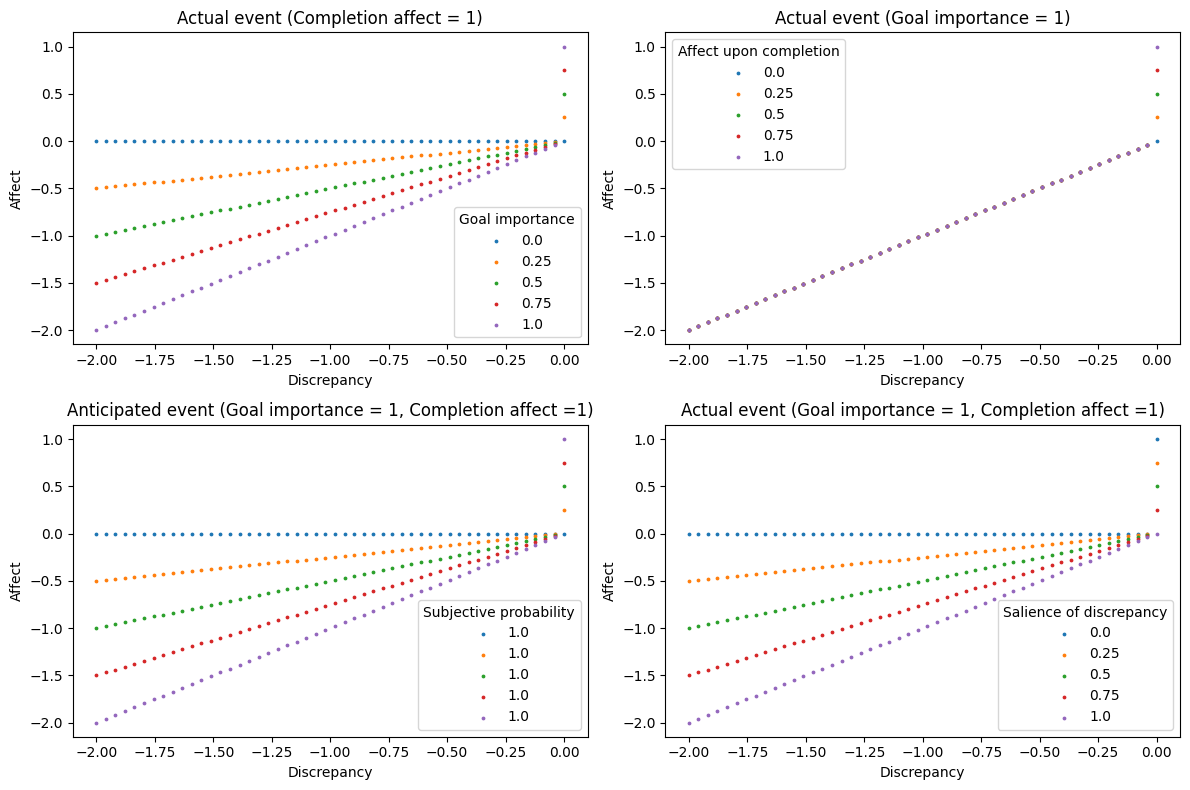

In [170]:
# Build up
s = 3

discrepancy = np.linspace(-2, 0)
goal_importance = np.linspace(0, 1, 5)
completion_affect = np.linspace(0, 1, 5)
subjective_probability = np.linspace(0, 1, 5)
salience_discrepancy = np.linspace(0, 1, 5)

def discrepancy_func(discrepancy, goal_importance=1, completion_affect=1, probability=1, salience_d = 1, salience_c = 1):
    affect = []
    for d in discrepancy:
        if d < 0:
            affect.append(salience_d *goal_importance * d * probability)
        else:
            affect.append(salience_c * goal_importance * completion_affect * probability)
    return affect

def delta_discrepancy_func(delta_discrepancy, goal_importance=1, probability=1, salience_delta_d = 1):
    affect = []
    for delta_d in delta_discrepancy:
        affect.append(salience_delta_d * goal_importance * delta_d * probability)
    return affect

fig, ax = plt.subplots(2, 2, figsize=[12,8])
axs = ax.flatten()
for w in goal_importance:
    axs[0].scatter(discrepancy, discrepancy_func(discrepancy, goal_importance=w), label=round(w,2), s=s)
axs[0].legend(title='Goal importance')
axs[0].set_xlabel('Discrepancy')
axs[0].set_ylabel('Affect')
axs[0].set_title('Actual event (Completion affect = 1)')

for r in completion_affect:
    axs[1].scatter(discrepancy, discrepancy_func(discrepancy, completion_affect=r), label=round(r,2), s=s)
axs[1].legend(title='Affect upon completion')
axs[1].set_xlabel('Discrepancy')
axs[1].set_ylabel('Affect')
axs[1].set_title('Actual event (Goal importance = 1)')

for p in subjective_probability:
    axs[2].scatter(discrepancy, discrepancy_func(discrepancy, probability=p), label=round(r,2), s=s)
axs[2].legend(title='Subjective probability')
axs[2].set_xlabel('Discrepancy')
axs[2].set_ylabel('Affect')
axs[2].set_title('Anticipated event (Goal importance = 1, Completion affect =1)')

for s_d in salience_discrepancy:
    axs[3].scatter(discrepancy, discrepancy_func(discrepancy, salience_d=s_d, salience_c=1-s_d), label=round(s_d,2), s=s)
axs[3].legend(title='Salience of discrepancy')
axs[3].set_xlabel('Discrepancy')
axs[3].set_ylabel('Affect')
axs[3].set_title('Actual event (Goal importance = 1, Completion affect =1)')

plt.tight_layout()

In [128]:
def gen_event_sequence(lims=[-1,0], length=100, p_completion=0.1):
    events = []
    for i in range(length):
        is_completion = np.random.uniform()
        if is_completion > p_completion:
            events.append(np.random.uniform(lims[0], lims[1]))
        else:
            events.append(0)
    return np.array(events)

Text(0.5, 1.0, 'Change in affect across time')

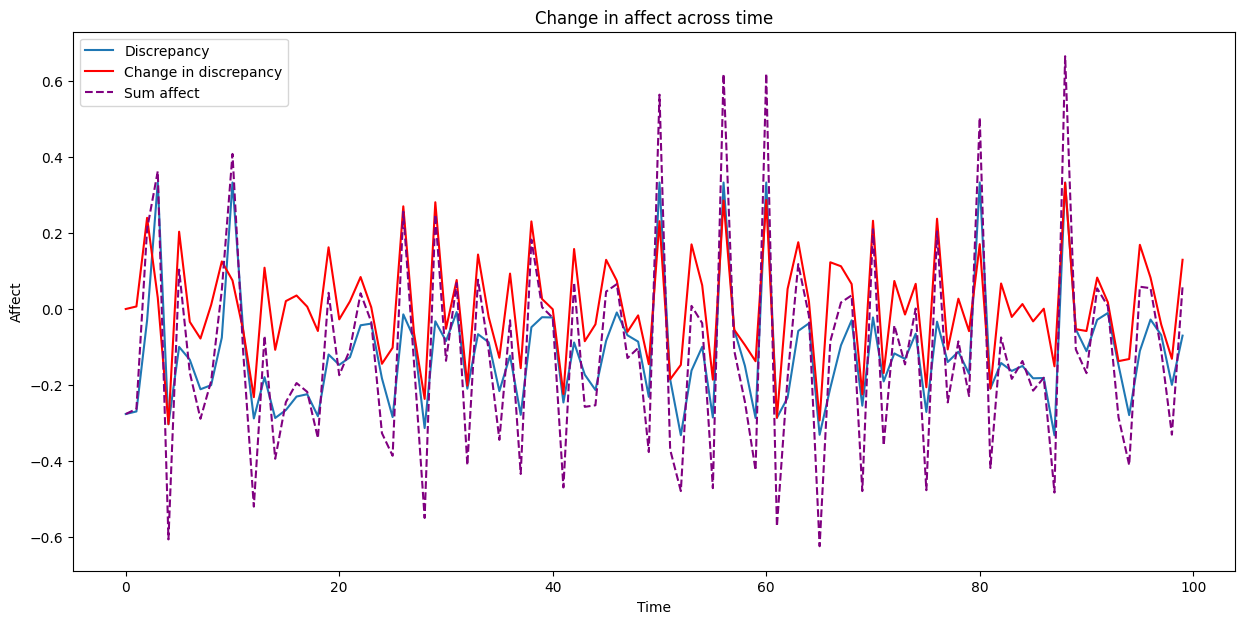

In [ ]:
# Across time
event_sequence = gen_event_sequence()
delta_sequence = np.insert(event_sequence[1:] - event_sequence[:-1], 0, 0)

saliences = {'discrepancy':1, 'delta_discrepancy':1, 'goal_completion':1}
total = sum(saliences.values())
saliences = {k: v / total for k, v in saliences.items()}

discrepancy_affect = discrepancy_func(event_sequence, goal_importance=1, completion_affect=1, probability=1, 
                                      salience_d=saliences['discrepancy'], salience_c=saliences['goal_completion'])
delta_discrepancy_affect = delta_discrepancy_func(delta_sequence, salience_delta_d=saliences['delta_discrepancy'])

combined_affect = [i + j for i, j in zip(discrepancy_affect, delta_discrepancy_affect)]

fig, ax = plt.subplots(1,1, figsize=[15,7])

ax.plot(discrepancy_affect, label='Discrepancy')
ax.plot(delta_discrepancy_affect, color='r', label='Change in discrepancy')
ax.plot(combined_affect, color='purple', linestyle='--', label = 'Sum affect')
ax.legend()
ax.set_xlabel('Time')
ax.set_ylabel('Affect')
ax.set_title('Change in affect across time')